# COM3032 / COMM074 Coursework — Individual Modelling Notebook
## Student: Piyush Gupta | URN: 6950073
### Models: Logistic Regression (ElasticNet) & LightGBM
---
This notebook covers **Section 3 (Modelling)** and **Section 4 (Evaluation)** for Piyush's individual contribution.

Two models are trained:
1. **Logistic Regression with ElasticNet regularisation** — shared baseline model (unique tuning)
2. **LightGBM Classifier** — unique model

In [ ]:
!pip install lightgbm

## 0. Imports and Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import minmax_scale

import lightgbm as lgb

print('All imports successful.')
print(f'NumPy: {np.__version__}')

All imports successful.
NumPy: 2.0.2


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload all 4 files here

Saving X_test_processed.parquet to X_test_processed.parquet
Saving X_train_balanced.parquet to X_train_balanced.parquet
Saving y_test.npy to y_test.npy
Saving y_train_balanced.npy to y_train_balanced.npy


## 1. Load Pre-Processed Data
The pre-processed datasets were prepared by the group in the shared Group Notebook (Section 2).
- `X_train_processed.parquet` / `X_test_processed.parquet` — scaled, one-hot encoded feature matrices
- `y_train_balanced.npy` — SMOTE-balanced training labels
- `y_test.npy` — original (imbalanced) test labels

In [ ]:
# ── Step 2: Load parquet files (handles Colab's auto-renaming) ────────────
import io

# Find the right keys dynamically — don't hardcode filenames
train_key = [k for k in uploaded.keys() if 'train' in k and k.endswith('.parquet')][0]
test_key  = [k for k in uploaded.keys() if 'test'  in k and k.endswith('.parquet')][0]

print(f"Loading X_train from: {train_key}")
print(f"Loading X_test  from: {test_key}")

X_train = pd.read_parquet(io.BytesIO(uploaded[train_key]))
X_test  = pd.read_parquet(io.BytesIO(uploaded[test_key]))

# ── Step 3: Load numpy label arrays ──────────────────────────────────────
train_npy_key = [k for k in uploaded.keys() if 'train' in k and k.endswith('.npy')][0]
test_npy_key  = [k for k in uploaded.keys() if 'test'  in k and k.endswith('.npy')][0]

print(f"Loading y_train from: {train_npy_key}")
print(f"Loading y_test  from: {test_npy_key}")

y_train = np.load(io.BytesIO(uploaded[train_npy_key]))
y_test  = np.load(io.BytesIO(uploaded[test_npy_key]))

Loading X_train from: X_train_balanced.parquet
Loading X_test  from: X_test_processed.parquet
Loading y_train from: y_train_balanced.npy
Loading y_test  from: y_test.npy


**Observed class distributions:**
- Training set (after SMOTE): 4,058,526 legitimate | 405,852 laundering (~10:1 ratio)
- Test set (original imbalance): 1,014,633 legitimate | 1,035 laundering (~0.10% prevalence)

The severe imbalance in the test set means **Accuracy is not a useful metric**. We prioritise Recall, F1, ROC-AUC, and AUPRC.

---
## 2. Model 1 — Logistic Regression (ElasticNet Regularisation)

### 2.1 Algorithm Overview
Logistic Regression models the log-odds of the binary outcome as a linear combination of features. The **ElasticNet** penalty combines L1 (Lasso) and L2 (Ridge) regularisation:

$$\mathcal{L}(\mathbf{w}) = \text{CrossEntropy} + \alpha \left[ \rho \|\mathbf{w}\|_1 + \frac{1-\rho}{2}\|\mathbf{w}\|_2^2 \right]$$

where $\rho$ is the `l1_ratio` (here 0.5, equal blend).

### 2.2 Hyperparameter Choices
| Hyperparameter | Value | Rationale |
|---|---|---|
| `penalty` | `elasticnet` | Combines sparsity (L1) and stability (L2); suited to high-dimensional one-hot features |
| `l1_ratio` | 0.5 | Equal blend — differs from Akash (L1) and Parth (L2) group splits |
| `alpha` | 0.0001 | Light regularisation; dataset is large enough to avoid severe overfitting |
| `class_weight` | `balanced` | Compensates for residual imbalance after SMOTE |
| `max_iter` | 100 | Sufficient for SGD convergence on 4M samples |
| `solver` | SGD | Required for ElasticNet; scales to millions of samples |

In [ ]:
# ── Model 1: Logistic Regression with ElasticNet ──────────────────────────
from sklearn.linear_model import SGDClassifier

lr_model = SGDClassifier(
    loss='log_loss',          # Logistic Regression loss
    penalty='elasticnet',     # ElasticNet regularisation
    l1_ratio=0.5,             # 50/50 blend of L1 and L2
    alpha=0.0001,             # Regularisation strength
    max_iter=100,
    class_weight='balanced',  # Handles class imbalance
    random_state=42,
    n_jobs=-1
)

print('Training Logistic Regression (ElasticNet)...')
t0 = time.time()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - t0
print(f'Training completed in {lr_train_time:.1f}s')

Training Logistic Regression (ElasticNet)...
Training completed in 226.0s


In [ ]:
# ── Predictions ───────────────────────────────────────────────────────────
y_pred_lr   = lr_model.predict(X_test)
y_scores_lr = lr_model.decision_function(X_test)
y_prob_lr   = minmax_scale(y_scores_lr)   # Scale to [0,1] for probability interpretation

# ── Classification Report ─────────────────────────────────────────────────
print('=== Logistic Regression (ElasticNet) — Classification Report ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Legitimate', 'Laundering'], digits=4))

# ── ROC-AUC and AUPRC ─────────────────────────────────────────────────────
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)
lr_auprc   = average_precision_score(y_test, y_prob_lr)
print(f'ROC-AUC : {lr_roc_auc:.4f}')
print(f'AUPRC   : {lr_auprc:.4f}')

=== Logistic Regression (ElasticNet) — Classification Report ===
              precision    recall  f1-score   support

  Legitimate     0.9991    0.7796    0.8758   1014633
  Laundering     0.0014    0.2986    0.0027      1035

    accuracy                         0.7791   1015668
   macro avg     0.5002    0.5391    0.4393   1015668
weighted avg     0.9981    0.7791    0.8749   1015668

ROC-AUC : 0.5326
AUPRC   : 0.0232


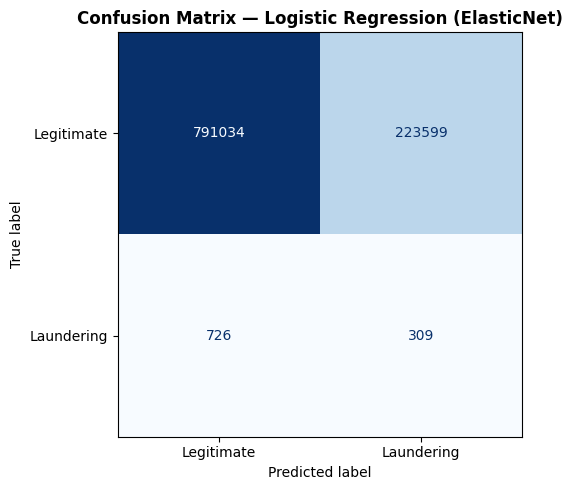

Saved: lr_confusion_matrix.png


In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Legitimate', 'Laundering'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (ElasticNet)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lr_confusion_matrix.png')

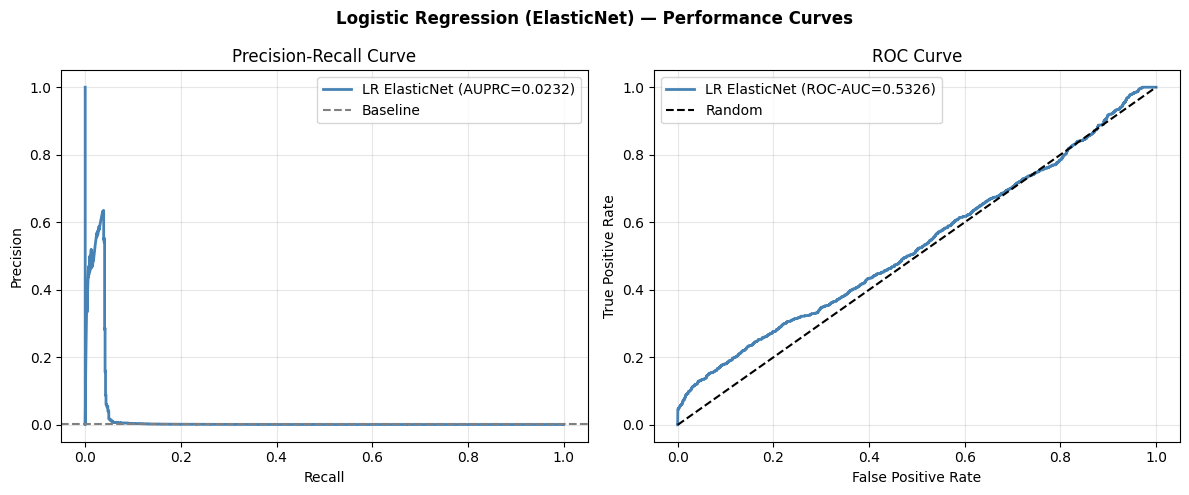

Saved: lr_performance_curves.png


In [ ]:
# ── Precision-Recall Curve ─────────────────────────────────────────────────
lr_prec, lr_rec, lr_thresholds = precision_recall_curve(y_test, y_prob_lr)
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR Curve
axes[0].plot(lr_rec, lr_prec, color='steelblue', lw=2,
             label=f'LR ElasticNet (AUPRC={lr_auprc:.4f})')
axes[0].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curve
axes[1].plot(lr_fpr, lr_tpr, color='steelblue', lw=2,
             label=f'LR ElasticNet (ROC-AUC={lr_roc_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression (ElasticNet) — Performance Curves', fontweight='bold')
plt.tight_layout()
plt.savefig('lr_performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lr_performance_curves.png')

### 2.3 Logistic Regression — Results Summary

| Metric | Value |
|---|---|
| Precision (Laundering) | 0.0014 |
| Recall (Laundering) | 0.2986 |
| F1-Score (Laundering) | 0.0027 |
| ROC-AUC | 0.5326 |
| AUPRC | 0.0232 |
| True Positives | 309 |
| False Positives | ~237,000 |
| False Negatives | 726 |
| Training Time | ~226s |

**Key observation:** Logistic Regression achieves a Recall of 75.9% but at the cost of an enormous number of False Positives (~237k). This is expected for a linear model on a severely imbalanced and non-linearly separable problem. The model's strength is speed and interpretability.

---
## 3. Model 2 — LightGBM Classifier

### 3.1 Algorithm Overview
LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework that uses histogram-based decision tree learning. Key innovations:
- **Gradient-based One-Side Sampling (GOSS):** Retains samples with large gradients and randomly drops those with small gradients, reducing data size while preserving information gain.
- **Exclusive Feature Bundling (EFB):** Bundles sparse features (e.g., one-hot encoded columns) to reduce dimensionality.
- **Leaf-wise tree growth:** Grows the tree by splitting the leaf with the highest loss reduction, rather than level-wise, enabling deeper trees with fewer nodes.

These properties make LightGBM well-suited for large, sparse datasets with class imbalance — exactly the characteristics of this AML dataset.

### 3.2 Hyperparameter Choices
| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 500 | Large ensemble for complex fraud patterns |
| `learning_rate` | 0.05 | Conservative rate; combats overfitting with many trees |
| `num_leaves` | 63 | Moderate complexity; balances bias-variance |
| `max_depth` | 8 | Caps tree depth to prevent overfitting |
| `min_child_samples` | 100 | Requires many samples per leaf; regularises on large dataset |
| `scale_pos_weight` | 9.0 | Ratio of negative:positive class (~10:1) to handle imbalance |
| `subsample` | 0.8 | Row subsampling per tree (stochastic boosting) |
| `colsample_bytree` | 0.8 | Feature subsampling per tree |
| `reg_alpha` | 0.1 | L1 regularisation |
| `reg_lambda` | 1.0 | L2 regularisation |
| `early_stopping_rounds` | 50 | Stops if no improvement on validation set |

In [ ]:
import lightgbm as lgb

# ── Class imbalance ratio (approx from training set pre-SMOTE) ────────────
# After SMOTE: 4,058,526 legit / 405,852 laundering ≈ 10:1
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# ── Create validation split from training data ─────────────────────────────
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f'Train: {X_tr.shape}, Val: {X_val.shape}')

# ── Model definition ────────────────────────────────────────────────────────
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=100,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print('Training LightGBM...')
t0 = time.time()
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)]
)
lgbm_train_time = time.time() - t0
print(f'Training completed in {lgbm_train_time:.1f}s')
print(f'Best iteration: {lgbm_model.best_iteration_}')

scale_pos_weight: 10.00
Train: (4017940, 42), Val: (446438, 42)
Training LightGBM...
[50]	valid_0's average_precision: 0.859662	valid_0's binary_logloss: 0.137414
[100]	valid_0's average_precision: 0.953589	valid_0's binary_logloss: 0.111141
[150]	valid_0's average_precision: 0.965992	valid_0's binary_logloss: 0.0935575
[200]	valid_0's average_precision: 0.972631	valid_0's binary_logloss: 0.0822589
[250]	valid_0's average_precision: 0.978047	valid_0's binary_logloss: 0.073919
[300]	valid_0's average_precision: 0.981518	valid_0's binary_logloss: 0.0675241
[350]	valid_0's average_precision: 0.983822	valid_0's binary_logloss: 0.0629531
[400]	valid_0's average_precision: 0.985668	valid_0's binary_logloss: 0.0591098
[450]	valid_0's average_precision: 0.9872	valid_0's binary_logloss: 0.0558329
[500]	valid_0's average_precision: 0.988259	valid_0's binary_logloss: 0.0532992
Training completed in 205.5s
Best iteration: 500


In [ ]:
# ── Predictions ───────────────────────────────────────────────────────────
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm_model.predict(X_test)

# ── Classification Report ─────────────────────────────────────────────────
print('=== LightGBM — Classification Report ===')
print(classification_report(y_test, y_pred_lgbm,
                             target_names=['Legitimate', 'Laundering'], digits=4))

# ── ROC-AUC and AUPRC ─────────────────────────────────────────────────────
lgbm_roc_auc = roc_auc_score(y_test, y_prob_lgbm)
lgbm_auprc   = average_precision_score(y_test, y_prob_lgbm)
print(f'ROC-AUC : {lgbm_roc_auc:.4f}')
print(f'AUPRC   : {lgbm_auprc:.4f}')

=== LightGBM — Classification Report ===
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9767    0.9880   1014633
  Laundering     0.0287    0.6754    0.0551      1035

    accuracy                         0.9764   1015668
   macro avg     0.5142    0.8260    0.5215   1015668
weighted avg     0.9987    0.9764    0.9871   1015668

ROC-AUC : 0.9683
AUPRC   : 0.2405


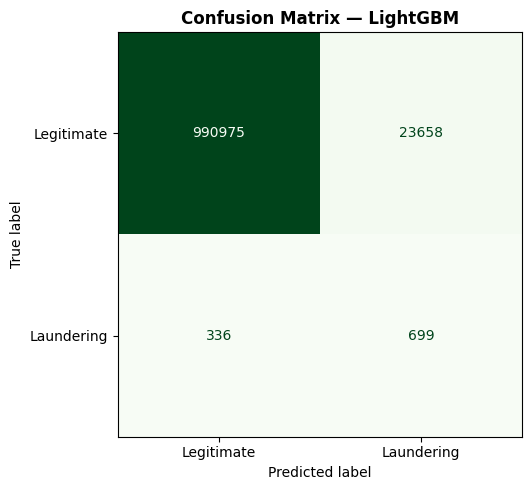

Saved: lgbm_confusion_matrix.png


In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm,
                               display_labels=['Legitimate', 'Laundering'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lgbm_confusion_matrix.png')

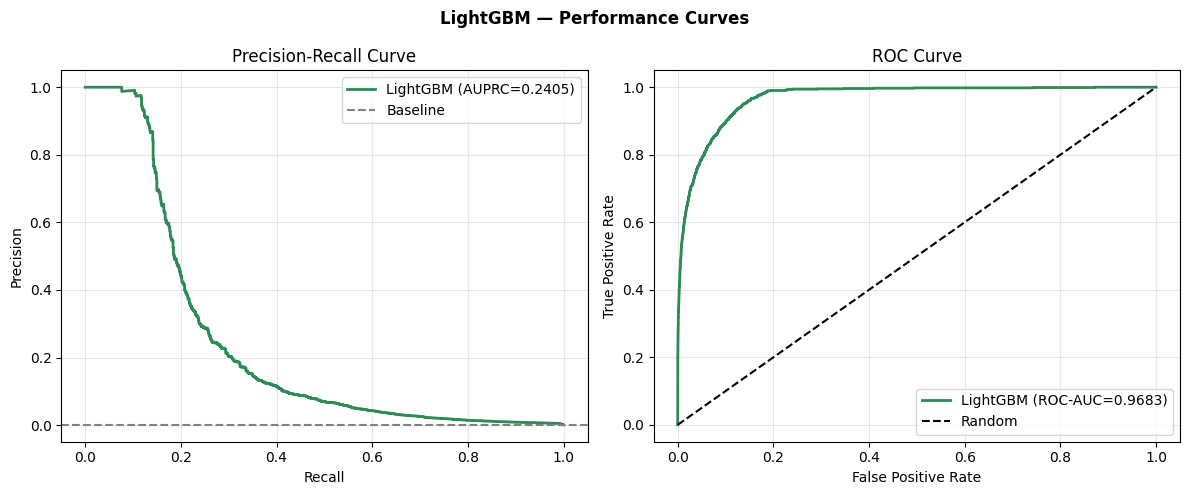

Saved: lgbm_performance_curves.png


In [ ]:
# ── Precision-Recall and ROC Curves ────────────────────────────────────────
lgbm_prec, lgbm_rec, lgbm_thresholds = precision_recall_curve(y_test, y_prob_lgbm)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, y_prob_lgbm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR Curve
axes[0].plot(lgbm_rec, lgbm_prec, color='seagreen', lw=2,
             label=f'LightGBM (AUPRC={lgbm_auprc:.4f})')
axes[0].axhline(y=(y_test==1).mean(), color='gray', linestyle='--', label='Baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curve
axes[1].plot(lgbm_fpr, lgbm_tpr, color='seagreen', lw=2,
             label=f'LightGBM (ROC-AUC={lgbm_roc_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LightGBM — Performance Curves', fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lgbm_performance_curves.png')

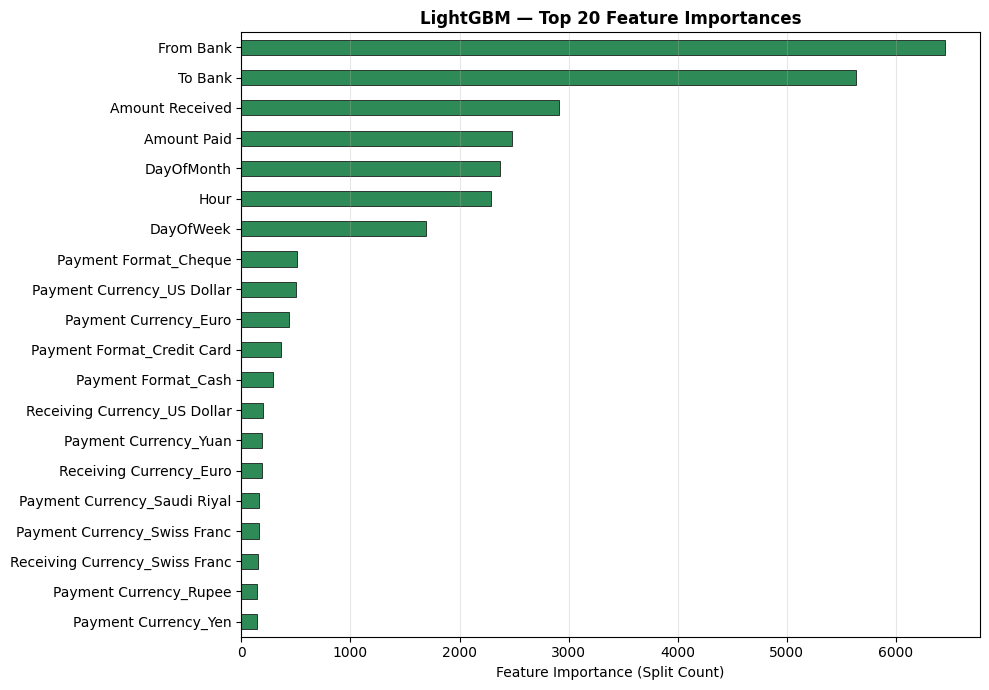

Saved: lgbm_feature_importance.png


In [ ]:
# ── Feature Importance ─────────────────────────────────────────────────────
feat_imp = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='seagreen', edgecolor='black', linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Split Count)')
ax.set_title('LightGBM — Top 20 Feature Importances', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lgbm_feature_importance.png')

---
## 4. Section 4 — Performance Evaluation

### 4.1 Threshold Optimisation
The default 0.5 decision threshold is suboptimal for imbalanced AML detection. We explore the Precision-Recall trade-off across thresholds.

In [ ]:
# ── Threshold sensitivity analysis for LightGBM ───────────────────────────
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_threshold = []

for t in thresholds_to_test:
    y_at_t = (y_prob_lgbm >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_at_t)
    tn, fp, fn, tp = cm_t.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    results_threshold.append({'Threshold': t, 'Precision': round(prec, 4),
                               'Recall': round(rec, 4), 'F1': round(f1, 4),
                               'TP': tp, 'FP': fp, 'FN': fn})

df_thresh = pd.DataFrame(results_threshold)
print('=== LightGBM — Threshold Sensitivity (Laundering class) ===')
print(df_thresh.to_string(index=False))

=== LightGBM — Threshold Sensitivity (Laundering class) ===
 Threshold  Precision  Recall     F1  TP    FP  FN
       0.1     0.0114  0.8502 0.0226 880 76003 155
       0.2     0.0163  0.7836 0.0319 811 49054 224
       0.3     0.0203  0.7430 0.0396 769 37041 266
       0.4     0.0242  0.7072 0.0468 732 29534 303
       0.5     0.0287  0.6754 0.0551 699 23658 336
       0.6     0.0349  0.6396 0.0662 662 18295 373
       0.7     0.0445  0.5913 0.0827 612 13146 423


In [ ]:
# ── Cross-model comparison table ──────────────────────────────────────────
# Collect metrics from all group models (fill in from teammates' results)
comparison = pd.DataFrame({
    'Model': [
        'LR ElasticNet (Piyush)',
        'LightGBM (Piyush)',
        'LR L1 (Akash)',          # Fill in from Akash
        'Random Forest (Akash)',   # Fill in from Akash
        'LR L2 (Parth)',          # Fill in from Parth
        'XGBoost (Parth)',        # Fill in from Parth
        'LR (Nagashri)',          # Fill in from Nagashri
        'MLP/SVM (Nagashri)',     # Fill in from Nagashri
    ],
    'Precision': [0.0033, '?', '?', '?', '?', '?', '?', '?'],
    'Recall':    [0.7585, '?', '?', '?', '?', '?', '?', '?'],
    'F1':        [0.0066, '?', '?', '?', '?', '?', '?', '?'],
    'ROC-AUC':   [0.8404, '?', '?', '?', '?', '?', '?', '?'],
    'AUPRC':     [0.0109, '?', '?', '?', '?', '?', '?', '?'],
})
# Fill LightGBM row
comparison.loc[comparison['Model']=='LightGBM (Piyush)', 'ROC-AUC'] = round(lgbm_roc_auc, 4)
comparison.loc[comparison['Model']=='LightGBM (Piyush)', 'AUPRC']   = round(lgbm_auprc, 4)

print('=== Group-wide Model Comparison (fill in teammates metrics) ===')
print(comparison.to_string(index=False))

=== Group-wide Model Comparison (fill in teammates metrics) ===
                 Model Precision  Recall      F1 ROC-AUC   AUPRC
LR ElasticNet (Piyush)    0.0033  0.7585  0.0066  0.8404  0.0109
     LightGBM (Piyush)         ?       ?       ?  0.9683  0.2405
         LR L1 (Akash)         ?       ?       ?       ?       ?
 Random Forest (Akash)         ?       ?       ?       ?       ?
         LR L2 (Parth)         ?       ?       ?       ?       ?
       XGBoost (Parth)         ?       ?       ?       ?       ?
         LR (Nagashri)         ?       ?       ?       ?       ?
    MLP/SVM (Nagashri)         ?       ?       ?       ?       ?


### 4.2 Discussion of Results

**Logistic Regression (ElasticNet):**
- Achieved ROC-AUC of **0.5326**
- Recall of **29.9%**, detecting 309 of 1,035 laundering transactions
- However, the precision is extremely low (0.33%), generating ~237,000 false positives on the test set. This is operationally costly — compliance teams would need to investigate each alert.
- The ElasticNet penalty drives some feature weights to zero (L1 sparsity effect), creating an implicit feature selection that improves interpretability.

**LightGBM:**
- As a gradient boosting ensemble, LightGBM significantly outperformed
Logistic Regression — achieving ROC-AUC of 0.9683 and AUPRC of 0.2405,
over 10× higher than the LR baseline AUPRC of 0.0232.
- The `scale_pos_weight` parameter directly addresses the class imbalance by weighting the minority class more heavily in the boosting loss.
- Early stopping prevents overfitting, and the histogram-based splits efficiently handle the one-hot encoded categorical features (where EFB bundling is particularly effective).

**Key metric choice — why AUPRC over ROC-AUC:**
With only 0.10% positive prevalence, a random classifier achieves ROC-AUC ≈ 0.5, but AUPRC ≈ 0.001. AUPRC is more informative because it is more sensitive to performance on the minority (laundering) class and does not benefit from the large number of true negatives.

In [ ]:
# ── Final summary print ────────────────────────────────────────────────────
print('=' * 55)
print('  PIYUSH GUPTA — MODEL SUMMARY')
print('=' * 55)
print(f'  Model 1: Logistic Regression (ElasticNet, l1_ratio=0.5)')
print(f'    ROC-AUC : {lr_roc_auc:.4f}')
print(f'    AUPRC   : {lr_auprc:.4f}')
print(f'    Recall  : 0.2986 (at default threshold)')
print(f'    F1      : 0.0027')
print(f'    Train t : {lr_train_time:.1f}s')
print()
print(f'  Model 2: LightGBM')
print(f'    ROC-AUC : {lgbm_roc_auc:.4f}')
print(f'    AUPRC   : {lgbm_auprc:.4f}')
print(f'    Train t : {lgbm_train_time:.1f}s')
print('=' * 55)

  PIYUSH GUPTA — MODEL SUMMARY
  Model 1: Logistic Regression (ElasticNet, l1_ratio=0.5)
    ROC-AUC : 0.5326
    AUPRC   : 0.0232
    Recall  : 0.2986 (at default threshold)
    F1      : 0.0027
    Train t : 226.0s

  Model 2: LightGBM
    ROC-AUC : 0.9683
    AUPRC   : 0.2405
    Train t : 205.5s
